# EDA(Exploratory data analysis ) 
#### data set which we use for EDA is  "dataset\retail_sales_dataset.csv"

## step1: Importing important liberaries

In [1]:
#import pandas for data manipulations
import pandas as pd 

#import numpy for numerical operations
import numpy as np 

#seaborn and matplotlib for data visuallization
import seaborn as sns 
import matplotlib.pyplot as plt

#date time for time series data
from datetime import datetime

#to avoid warnings
import warnings
warnings.filterwarnings("ignore")

#setting style for visuallization
try:
   plt.style.use("seaborn-v0_8-darkgrid")
except:
    try:
        plt.style.use("seaborn-darkgrid")
    except:
        plt.style.use("ggplot")


sns.set_palette('husl')

#Display settings
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
pd.set_option("display.float_format", lambda x : "%.2f" % x)



## step2: load the dataset

In [2]:
df=pd.read_csv("C:\\Users\\HS\\AI With python\\dataset\\retail_sales_dataset.csv")
# Display Basic Information
print(f"Dataset Shape : {df.shape}")
print("\n First few rows ")
df.head()

Dataset Shape : (1000, 9)

 First few rows 


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## step3: BASIC INFORMATION VIEW

In [3]:
print(f"=== DATASET BASIC INFORMATION===")
print(f"Data Dimensions : {df.shape[0]} rows  ,{df.shape[1]} columns")
print(f"Columns Names and thier types")
print(f"\n {df.dtypes}")

=== DATASET BASIC INFORMATION===
Data Dimensions : 1000 rows  ,9 columns
Columns Names and thier types

 Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


# step4 : Missing values detection

In [4]:
print("===MISSING VALUES===\n")
print(f"{df.isnull().sum()}")
print(f"===Dataset Summary===")
print(f"\n {df.info()}")

===MISSING VALUES===

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
===Dataset Summary===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

 None


## step5:Datatype Conversion and cleaning

In [ ]:
print("===Datatype Conversion and cleaning===")
df["Date"]=pd.to_datetime(df['Date'])

# Extract additional columns
df["Month"]=df["Date"].dt.month
df["Year"]=df["Date"].dt.year
df["Quarter"]=df["Date"].dt.quarter
df['DayOfWeek']=df["Date"].dt.day_of_week
df["Monthname"]=df["Date"].dt.strftime('%B')
df["YearMonth"]=df["Date"].dt.to_period('M')
df["Day"]=df["Date"].dt.day_name()

#convert categorical column  type  (str to category)
categorical_columns=["Gender","Product Category"]
for col in categorical_columns:
    df[col]=df[col].astype("category")
    
#Ensure that numerical columns are properly formated
numerical_columns=["Age","Price per Unit","Total Amount","Quantity"]

for  col in numerical_columns:
    df[col]=pd.to_numeric(df[col],errors="coerce")

print("Date type after conversion")
df.info()
print(f" Date Range  {df['Date'].min()} to {df['Date'].max()}")
df.head()

===Datatype Conversion and cleaning===
Date type after conversion
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   category      
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   category      
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
 10  Year              1000 non-null   int32         
 11  Quarter           1000 non-null   int32         
 12  DayOfWeek         1000 non-null   int32         
 13  Monthname         1000 n

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Quarter,DayOfWeek,Monthname,YearMonth
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,4,4,November,2023-11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,1,0,February,2023-02
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,1,4,January,2023-01
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,2,6,May,2023-05
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,2,5,May,2023-05


## step6: Basic Statistical Summary

In [6]:
#Basic Statistical Summary
print("===  STATISTICAL SUMMARY  ===")
print("Descriptive summary of  numerical_columns")
numerical_columns=df[["Age","Price per Unit","Total Amount","Quantity"]]
print(numerical_columns.describe())


===  STATISTICAL SUMMARY  ===
Descriptive summary of  numerical_columns
          Age  Price per Unit  Total Amount  Quantity
count 1000.00         1000.00       1000.00   1000.00
mean    41.39          179.89        456.00      2.51
std     13.68          189.68        560.00      1.13
min     18.00           25.00         25.00      1.00
25%     29.00           30.00         60.00      1.00
50%     42.00           50.00        135.00      3.00
75%     53.00          300.00        900.00      4.00
max     64.00          500.00       2000.00      4.00


In [7]:
print("\n Category_Wise Summary")
category_summary= df.groupby("Product Category").agg({
    "Total Amount": ["count","sum","mean","std"],
    "Quantity":["sum","mean"]}).round(2)
category_summary
    


 Category_Wise Summary


Total Amount                       Quantity     
                        count     sum   mean    std      sum mean
Product Category                                                 
Beauty                    307  143515 467.48 563.61      771 2.51
Clothing                  351  155580 443.25 550.70      894 2.55
Electronics               342  156905 458.79 567.54      849 2.48

In [8]:
print("=== Gender wise  Summary===")
gender_summary=df.groupby("Gender").agg({
   "Total Amount": ["count","sum","mean","std"],
    "Quantity":["sum","mean"]
}).round(2)
gender_summary

=== Gender wise  Summary===


Total Amount                       Quantity     
              count     sum   mean    std      sum mean
Gender                                                 
Female          510  232840 456.55 554.30     1298 2.55
Male            490  223160 455.43 566.43     1216 2.48

In [9]:
#Monthly sales trend Analysis
print("===   Monthly Sale Trend    ===")
monthly_sales=df.groupby(["Month","Monthname"]).agg({
    "Total Amount":"sum",
    "Quantity":"sum",
    "Price per Unit":"sum"
}).round(2)

monthly_sales

===   Monthly Sale Trend    ===


,,Total Amount,Quantity,Price per Unit
Month,Monthname,,,
1,January,36980,199,14645
2,February,44060,214,16255
3,March,28990,194,12620
4,April,33870,214,12715
5,May,53150,259,21255
6,June,36715,197,14210
7,July,35465,176,15295
8,August,36960,227,15465
9,September,23620,170,8895


In [10]:
#   Check for any remaining issues 

print("===  Data Quality Check  ")
print(f"Total number of rowns : {len(df)}")
print(f"\nMissing values in Amount column: {df['Total Amount'].isna().sum()}")
print(f"\nRows with values negative or zero {(df['Total Amount']<=0).isna().sum()}")

# Remove rows with invalid data if any
df_clean = df.dropna(subset=['Total Amount', 'Date']).copy() # deleterows with null values and copy the data to save original data 
df_clean = df_clean[df_clean['Total Amount'] > 0].copy() # copy the rows which have not any negative value

print(f"\nCleaned dataset rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

===  Data Quality Check  
Total number of rowns : 1000

Missing values in Amount column: 0

Rows with values negative or zero 0

Cleaned dataset rows: 1000
Rows removed: 0


## step7: Data Visuallization

In [11]:
# Monthly Sales trend Analysis
print("===  MONTHLY SALES TREND ANALYSIS")
# Calculate monthly sales 
monthly_sales=df.groupby(['Month','Monthname']).agg({
    "Total Amount": "sum",
    "Quantity"    : "sum"
}).reset_index()
monthly_sales=monthly_sales.sort_values("Month")
monthly_sales
print(f"Maximum sale value {(monthly_sales['Total Amount'].max())}")
print(f"Minimum sale value {(monthly_sales['Total Amount'].min())}")

===  MONTHLY SALES TREND ANALYSIS
Maximum sale value 53150
Minimum sale value 23620


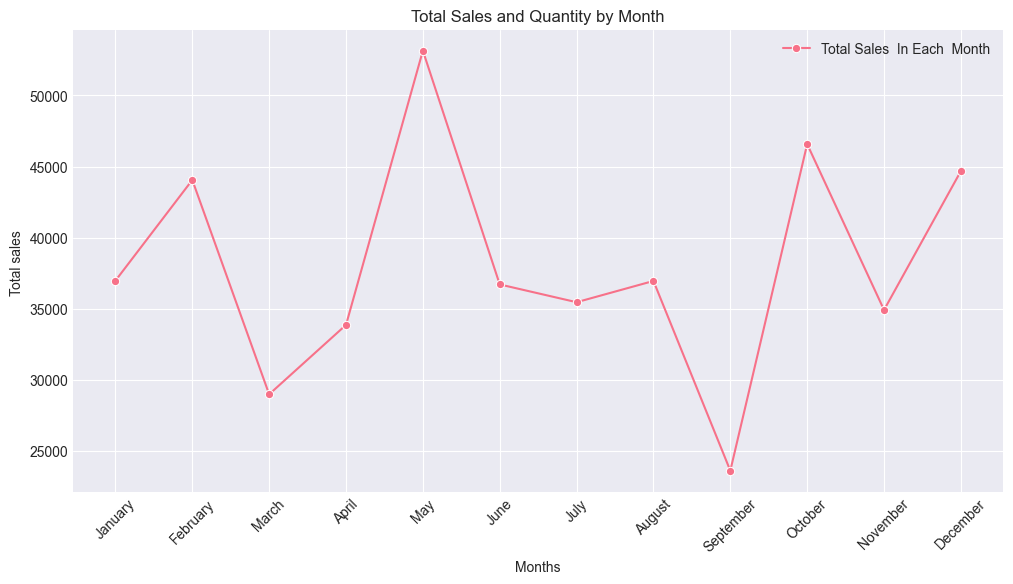

In [12]:
plt.figure(figsize=(12,6))

# Sales line plot
sns.lineplot(
    data=monthly_sales,
    x='Monthname',
    y='Total Amount',
    marker='o',
    label='Total Sales  In Each  Month'

)

# Titles and labels
plt.title('Total Sales and Quantity by Month')
plt.xlabel('Months')
plt.ylabel('Total sales ')

# Rotate month names
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show plot
plt.show()

In [13]:
# Category performance analysis
print("     === CATEGORY PERFORMANCE ANALYSIS===    ")
categical_summary=df.groupby("Product Category").agg({
    "Total Amount": "sum",
    "Quantity":"sum"
}).sort_values("Total Amount",ascending=False)
print("Categorical performanc (According to sale)")
print(category_summary)

     === CATEGORY PERFORMANCE ANALYSIS===    
Categorical performanc (According to sale)
                 Total Amount                       Quantity     
                        count     sum   mean    std      sum mean
Product Category                                                 
Beauty                    307  143515 467.48 563.61      771 2.51
Clothing                  351  155580 443.25 550.70      894 2.55
Electronics               342  156905 458.79 567.54      849 2.48


In [14]:
df_clean.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Year', 'Quarter', 'DayOfWeek', 'Monthname', 'YearMonth'],
      dtype='str')

Text(0.5, 1.0, 'Market Share by Category')

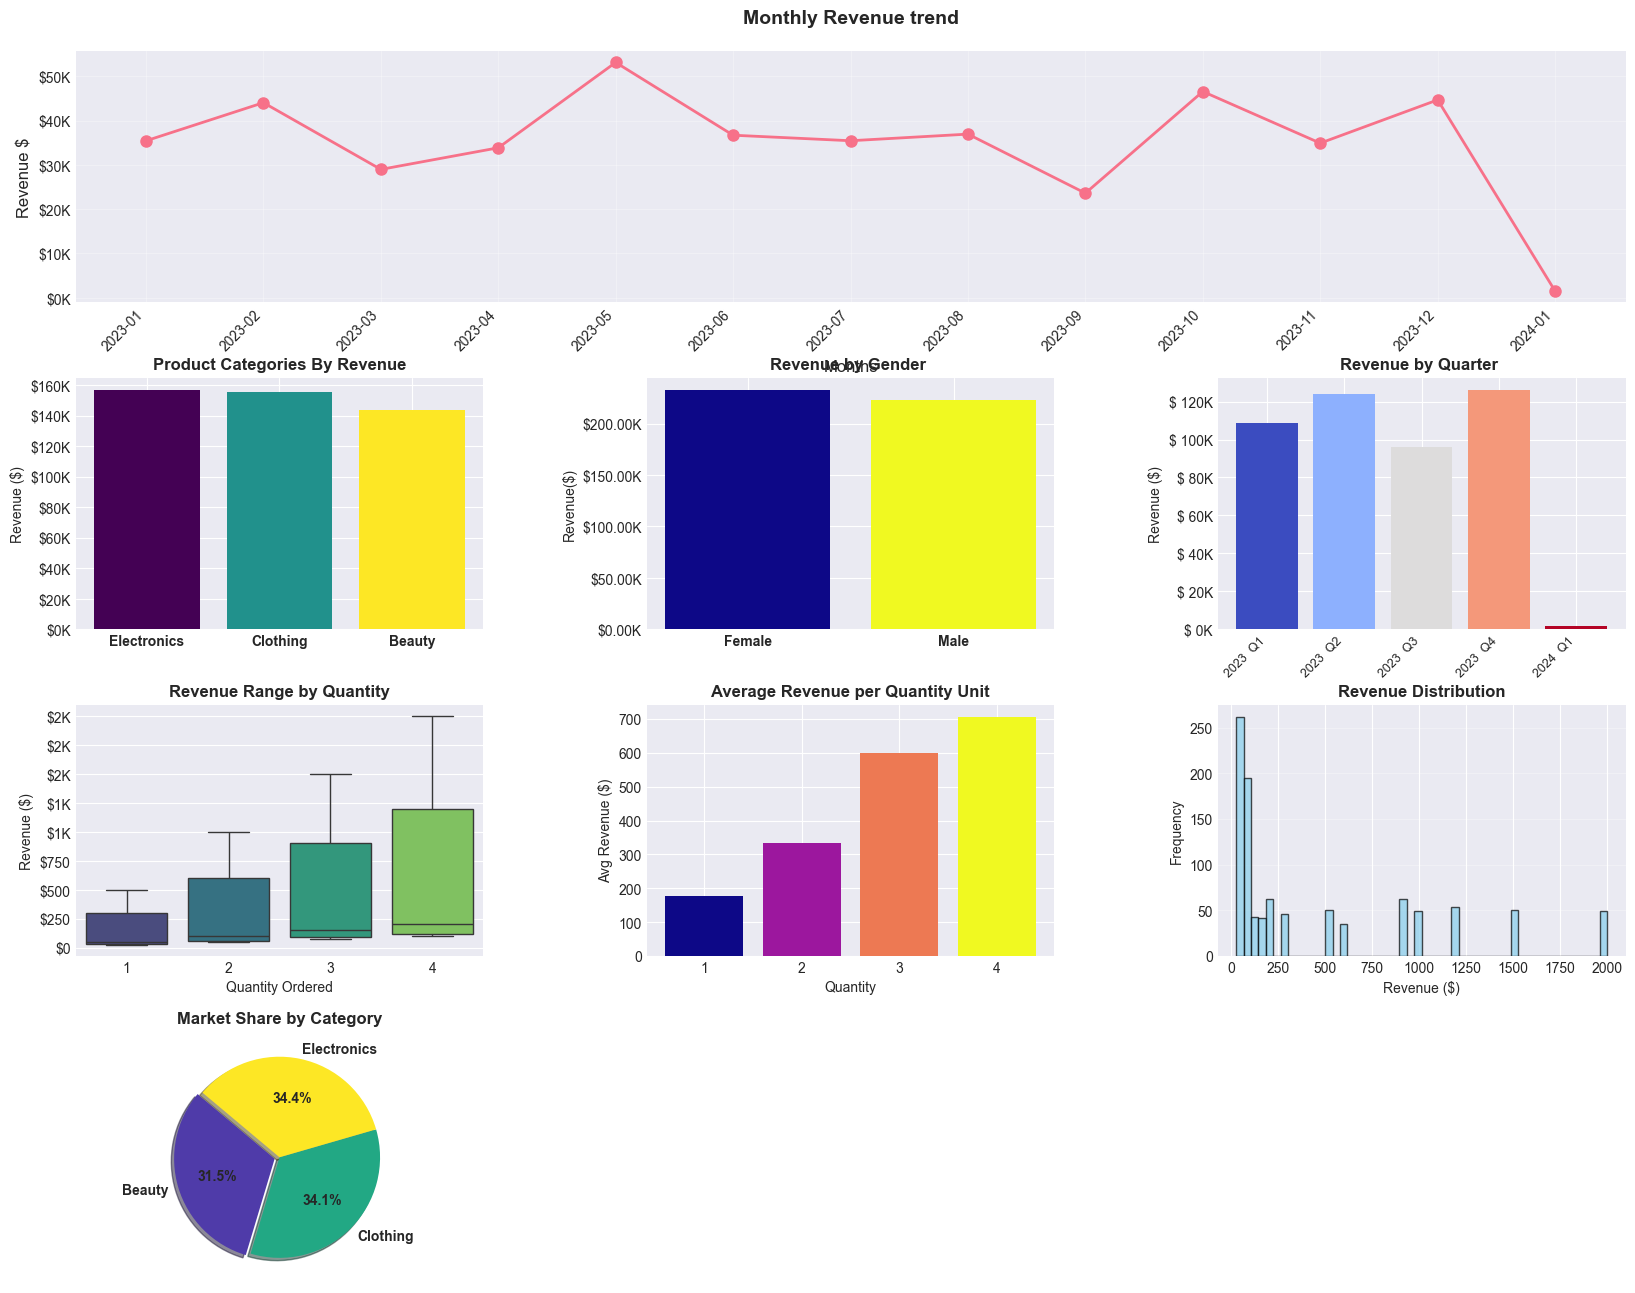

In [ ]:
# setup the plotting style
plt.rcParams["figure.figsize"]=(15,10)  # default figsize(15,10)
plt.rcParams["font.size"]=10  # font size of text in graph


# Creating a comprehenisve dashboard 
fig = plt.figure(figsize=(20,16))   # Create a empty dashboard 
gs=fig.add_gridspec(4,3,hspace=0.3,wspace=0.4)  # divide figure into 3 rows and four categorical_columns

#1 Revenue Trend overtime
ax1=fig.add_subplot(gs[0,:])
monthly_revenue=df_clean.groupby("YearMonth")["Total Amount"].sum()
monthly_revenue.index=monthly_revenue.index.astype(str)
ax1.plot(monthly_revenue.index,monthly_revenue.values,marker="o",linewidth=2,markersize=8)
ax1.set_title("Monthly Revenue trend",fontsize=14,fontweight="bold",pad=20)
ax1.set_xlabel("Months",fontsize=12)
ax1.set_ylabel("Revenue $",fontsize=12)
ax1.grid(True,alpha=0.3)
ax1.tick_params(axis="x",rotation=45)
plt.setp(ax1.xaxis.get_majorticklabels(),rotation=45,ha="right")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda  x,p:f"${x/1000:.0f}K"))


#2Revenue by product_category
ax2=fig.add_subplot(gs[1,0])
product_category=df_clean.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
colors=plt.cm.viridis(np.linspace(0,1,len(product_category)))
ax2.bar(range(len(product_category)),product_category.values,color=colors)
ax2.set_xticks(range(len(product_category)))
ax2.set_xticklabels(product_category.index, fontsize=10, fontweight="bold")
ax2.set_title("Product Categories By Revenue",fontsize=12,fontweight="bold")
ax2.set_ylabel("Revenue ($)",fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f"${x/1000:.0f}K"))


#3 Revenue by Gender 
ax3=fig.add_subplot(gs[1,1])
Revenue_by_Gender=df_clean.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)
colors=plt.cm.plasma(np.linspace(0,1,len(Revenue_by_Gender)))
ax3.bar(range(len(Revenue_by_Gender)),Revenue_by_Gender.values,color=colors)
ax3.set_xticks(range(len(Revenue_by_Gender)))
ax3.set_xticklabels(Revenue_by_Gender.index,fontsize=10, fontweight="bold")
ax3.set_title("Revenue by Gender ",fontsize=12,fontweight="bold")
ax3.set_ylabel("Revenue($)",fontsize=10)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f"${x/1000:.2f}K"))


# 4. Revenue Distribution by Quarter
ax4= fig.add_subplot(gs[1,2])
Revenue_by_quarter=df_clean.groupby(["Year","Quarter"])["Total Amount"].sum().reset_index()
Revenue_by_quarter["Quarter Label"]=Revenue_by_quarter["Year"].astype(str) + "  Q" + Revenue_by_quarter["Quarter"].astype(str)
colors=plt.cm.coolwarm(np.linspace(0,1,len(Revenue_by_quarter)))
ax4.bar(range(len(Revenue_by_quarter)),Revenue_by_quarter["Total Amount"],color=colors)
ax4.set_xticks(range(len(Revenue_by_quarter)))
ax4.set_xticklabels(Revenue_by_quarter["Quarter Label"],rotation=45,ha="right",fontsize=9)
ax4.set_title("Revenue by Quarter ",fontsize=12,fontweight="bold")
ax4.set_ylabel("Revenue ($)",fontsize=10)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f"$ {x/1000:.0f}K"))

#5 Box Plot: Quantity vs Revenue
import seaborn as sns
ax5 = fig.add_subplot(gs[2, 0])

sns.boxplot(x='Quantity', y='Total Amount', data=df_clean, palette='viridis', ax=ax5)

ax5.set_title('Revenue Range by Quantity', fontsize=12, fontweight='bold')
ax5.set_xlabel('Quantity Ordered', fontsize=10)
ax5.set_ylabel('Revenue ($)', fontsize=10)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K' if x >= 1000 else f'${x:.0f}'))

#6 Bar Chart: Average Revenue per Quantity
ax6 = fig.add_subplot(gs[2,1])

avg_rev = df_clean.groupby('Quantity')['Total Amount'].mean()
ax6.bar(avg_rev.index.astype(str), avg_rev.values, color=plt.cm.plasma(np.linspace(0, 1, len(avg_rev))))
ax6.set_title('Average Revenue per Quantity Unit', fontsize=12, fontweight='bold')
ax6.set_xlabel('Quantity', fontsize=10)
ax6.set_ylabel('Avg Revenue ($)', fontsize=10)

#7 Distirbution of Revenue
ax7=fig.add_subplot(gs[2,2])
ax7.hist(df_clean["Total Amount"],bins=50,color="skyblue",edgecolor="black",alpha=0.7)
ax7.set_title('Revenue Distribution', fontsize=12, fontweight='bold')
ax7.set_xlabel('Revenue ($)', fontsize=10)
ax7.set_ylabel('Frequency', fontsize=10)
ax7.grid(True, alpha=0.3, axis='y')

# Product Category wise Revenue Distribution
ax8 = fig.add_subplot(gs[3, 0])

# Data ko prepare karna
category_revenue = df_clean.groupby("Product Category")["Total Amount"].sum()

# Colors aur design
colors = ['#4F3BA9', '#22A884', '#FDE725'] # Viridis shades se milte julte colors
explode = (0.05, 0, 0)  # Pehli category ko thora bahar nikalne ke liye (Style)

# Pie chart create karna
ax8.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 10, 'fontweight': 'bold'})

ax8.set_title("Market Share by Category", fontsize=12, fontweight='bold')


# Days of Week Sales Trend
ax9 = fig.add_subplot(gs[3, 1:3]) 
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df_clean.groupby('Day')['Total Amount'].sum().reindex(days_order)
ax9.plot(day_sales.index, day_sales.values, marker='o', linestyle='-', 
         color='#FF5733', linewidth=2.5, markersize=8)
ax9.set_title('Weekly Sales Trend', fontsize=12, fontweight='bold')
ax9.set_xlabel('Day of the Week', fontsize=10)
ax9.set_ylabel('Total Sales ($)', fontsize=10)
ax9.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: 
f'${x/1000:.0f}K' if x >= 1000 else f'${x:.0f}'))
ax9.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
